# Desafio 2.1 Machine Learning em Python

Para este desafio, você irá utilizar um conjunto de dados com aproximadamente 52 carros usados das empresas atutotrader e carfax. A base de dados "cars.csv" contém um conjunto de características sobre carros usados, tais como marca, modelo, ano, quilometragem, quilometragem urbana e rodoviária, potência, torque, capacidade do motor, capacidade de combustível, número de cilindros, número de assentos, número de propietários, preço, link, condição, tipo, número de portas, tração nas rodas, tipo de motor, níveis de velocidade, altura livre dianteira, espaço para pernas dianteiro, altura livre traseora, espaço para pernas traseiro e registros de serviço.

## Passo 1

Utilizando a biblioteca de manipulação de dados, o Pandas, realize o upload da base de dados no Python para iniciar as análises.

Ainda utilizando as ferramentas do Pandas, realize análises estatísticas descritivas sobre os dados, explorando todas as variáveis do modelo: variáveis qualitativas e quantitativas.

In [451]:
import pandas as pd

In [452]:
df = pd.read_csv('cars.csv')

In [453]:
df.tail()

,id,brand,model,year,miles,city_mileage,highway_mileage,horsepower,torque,engine_capacity_litre,...,type,doors,wheel_drive,engine_type,speed_levels,front_headroom,front_legroom,rear_headroom,rear_legroom,service_records
47,53,Hyundai,Sonata,2019,33412,23,32,245,260,2.0,...,sedan,4,2,gas,8.0,40.4,45.5,38.0,35.6,10
48,54,Hyundai,Elantra SE,2020,13830,30,40,147,132,2.0,...,sedan,4,2,gas,6.0,40.3,42.2,37.3,35.7,6
49,55,Ford,Fusion,2019,23507,20,29,245,275,2.0,...,sedan,4,2,gas,6.0,39.2,44.3,37.8,38.3,11
50,56,Hyundai,Elantra SE,2020,11296,30,40,147,132,2.0,...,sedan,4,2,gas,6.0,40.3,42.2,37.3,35.7,7
51,57,Honda,Accord,2018,82729,30,38,192,192,1.5,...,sedan,4,2,gas,6.0,39.5,42.3,37.3,40.4,9


In [454]:
df.shape

(52, 27)

### Lidando com nulos e duplicatas

In [455]:
df.isnull().sum().sum()

np.int64(52)

In [456]:
df.isnull().sum()

,0
id,0
brand,0
model,0
year,0
miles,0
city_mileage,0
highway_mileage,0
horsepower,0
torque,0
engine_capacity_litre,0


In [457]:
df['condition'].unique()

array([nan,  4.])

In [458]:
df['speed_levels'].unique()

array([ 6., nan,  8.,  7.,  9.])

In [459]:
df.columns

Index(['id', 'brand', 'model', 'year', 'miles', 'city_mileage',
       'highway_mileage', 'horsepower', 'torque', 'engine_capacity_litre',
       'fuel_capacity', 'num_cylinder', 'num_seat', 'num_owners', 'price',
       'link', 'condition', 'type', 'doors', 'wheel_drive', 'engine_type',
       'speed_levels', 'front_headroom', 'front_legroom', 'rear_headroom',
       'rear_legroom', 'service_records'],
      dtype='object')

In [460]:
# Tirando a coluna condition
df.drop(columns=['condition'], inplace=True)
df.shape

(52, 26)

In [461]:
# Tirando a linha nula de speed_levels
df.dropna(axis=0, inplace= True)
df.shape

(51, 26)

In [462]:
df.duplicated().sum()

np.int64(0)

### Analisando os dados





In [463]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, 0 to 51
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     51 non-null     int64  
 1   brand                  51 non-null     object 
 2   model                  51 non-null     object 
 3   year                   51 non-null     int64  
 4   miles                  51 non-null     int64  
 5   city_mileage           51 non-null     int64  
 6   highway_mileage        51 non-null     int64  
 7   horsepower             51 non-null     int64  
 8   torque                 51 non-null     int64  
 9   engine_capacity_litre  51 non-null     float64
 10  fuel_capacity          51 non-null     float64
 11  num_cylinder           51 non-null     int64  
 12  num_seat               51 non-null     int64  
 13  num_owners             51 non-null     int64  
 14  price                  51 non-null     int64  
 15  link         

In [464]:
df.describe().round(2)

,id,year,miles,city_mileage,highway_mileage,horsepower,torque,engine_capacity_litre,fuel_capacity,num_cylinder,...,num_owners,price,doors,wheel_drive,speed_levels,front_headroom,front_legroom,rear_headroom,rear_legroom,service_records
count,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,...,51.00,51.00,51.0,51.00,51.00,51.00,51.00,51.00,51.00,51.00
mean,31.73,2018.69,33984.14,28.75,37.37,176.18,179.47,1.84,14.37,4.04,...,1.35,21660.76,4.0,2.16,6.31,38.67,42.47,37.24,37.66,7.43
std,15.31,1.41,22918.58,5.61,4.16,33.76,46.38,0.38,2.42,0.28,...,0.63,3488.39,0.0,0.54,0.76,0.93,1.05,0.45,1.61,4.70
min,3.00,2014.00,5000.00,17.00,24.00,143.00,99.00,1.40,8.90,4.00,...,1.00,13590.00,4.0,2.00,6.00,37.50,41.10,35.80,33.20,1.00
25%,19.50,2018.00,16328.50,26.00,35.50,152.00,138.00,1.50,12.40,4.00,...,1.00,19496.00,4.0,2.00,6.00,37.65,42.20,37.05,37.40,4.00
50%,32.00,2019.00,27440.00,30.00,38.00,159.00,184.00,2.00,14.00,4.00,...,1.00,21998.00,4.0,2.00,6.00,38.50,42.30,37.20,37.40,6.00
75%,44.50,2019.50,43085.00,30.00,40.00,192.00,192.00,2.00,15.30,4.00,...,2.00,22994.00,4.0,2.00,6.00,39.30,42.40,37.50,38.30,10.00
max,57.00,2022.00,97027.00,55.00,49.00,288.00,294.00,3.50,19.00,6.00,...,3.00,33777.00,4.0,4.00,9.00,40.40,45.50,38.00,40.40,26.00


In [465]:
df.columns

Index(['id', 'brand', 'model', 'year', 'miles', 'city_mileage',
       'highway_mileage', 'horsepower', 'torque', 'engine_capacity_litre',
       'fuel_capacity', 'num_cylinder', 'num_seat', 'num_owners', 'price',
       'link', 'type', 'doors', 'wheel_drive', 'engine_type', 'speed_levels',
       'front_headroom', 'front_legroom', 'rear_headroom', 'rear_legroom',
       'service_records'],
      dtype='object')

In [466]:
df['brand'].unique()

array(['Chevrolet', 'Hyundai', 'Ford', 'Honda', 'Subaru', 'Volkswagen'],
      dtype=object)

In [467]:
df['model'].unique()

array(['Volt LT', 'Elantra SE', 'Focus', 'Civic', 'Legacy', 'Jetta',
       'Accord', 'Impreza', 'Insight', 'Taurus', 'Fusion', 'Malibu',
       'Passat', 'Sonata'], dtype=object)

In [468]:
df['type'].unique()

array(['sedan'], dtype=object)

In [469]:
df.drop(columns=['type'], inplace=True)

In [470]:
df.drop(columns=['link'], inplace=True)

In [471]:
df.groupby('brand')['price'].describe().sort_values(by='mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
brand,,,,,,,,
Subaru,3.0,26175.000000,6583.540005,22360.0,22374.0,22388.0,28082.5,33777.0
Chevrolet,3.0,22724.666667,3431.989268,18949.0,21259.5,23570.0,24612.5,25655.0
Honda,22.0,22375.545455,2696.540548,17488.0,20146.0,22582.0,22994.0,26988.0
Volkswagen,11.0,20634.000000,3051.706899,15795.0,18439.5,19877.0,22745.0,25460.0
Hyundai,7.0,19985.000000,3520.649514,15590.0,17390.0,19542.0,22246.0,25491.0
Ford,5.0,19773.800000,3646.012301,13590.0,19795.0,20900.0,21591.0,22993.0


In [472]:
df.groupby('model')['price'].describe().sort_values(by='mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Legacy,1.0,33777.000000,NaN,33777.0,33777.00,33777.0,33777.00,33777.0
Volt LT,1.0,25655.000000,NaN,25655.0,25655.00,25655.0,25655.00,25655.0
Accord,7.0,24419.571429,2983.411518,19403.0,22489.50,25991.0,26788.00,26988.0
Taurus,1.0,22993.000000,NaN,22993.0,22993.00,22993.0,22993.00,22993.0
Impreza,2.0,22374.000000,19.798990,22360.0,22367.00,22374.0,22381.00,22388.0
Insight,1.0,21998.000000,NaN,21998.0,21998.00,21998.0,21998.00,21998.0
Sonata,3.0,21992.333333,3773.990108,17993.0,20243.00,22493.0,23992.00,25491.0
Civic,14.0,21380.500000,2076.295360,17488.0,19998.00,22235.0,22965.75,24498.0
Malibu,2.0,21259.500000,3267.540436,18949.0,20104.25,21259.5,22414.75,23570.0


In [473]:
df.groupby('brand')['model'].unique()

,model
brand,
Chevrolet,"[Volt LT, Malibu]"
Ford,"[Focus, Taurus, Fusion]"
Honda,"[Civic, Accord, Insight]"
Hyundai,"[Elantra SE, Sonata]"
Subaru,"[Legacy, Impreza]"
Volkswagen,"[Jetta, Passat]"


## Passo 2

Utilize bibliotecas de visualização de dados em Python para realizar a análise exploratória dos dados, utilizando técnicas de storytelling

In [474]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='brand'>

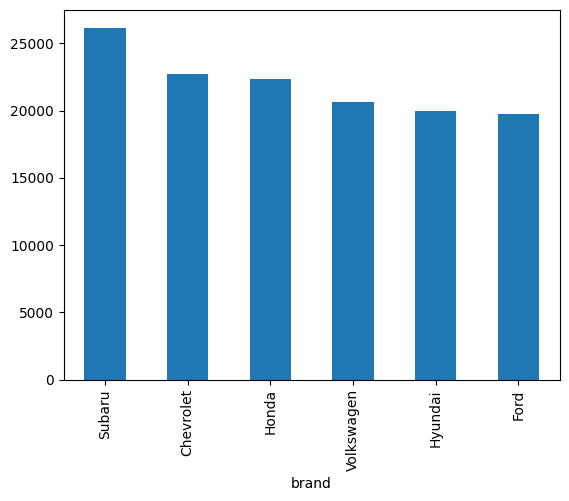

In [475]:
df_marcas_medias = df.groupby('brand')['price'].mean().sort_values(ascending=False)
df_marcas_medias.plot(kind='bar')

<Axes: xlabel='brand'>

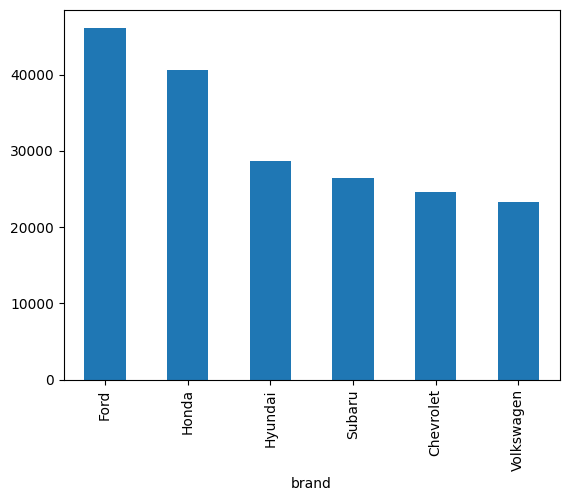

In [476]:
df_marcas_milhagem = df.groupby('brand')['miles'].mean().sort_values(ascending=False)
df_marcas_milhagem.plot(kind='bar')

<Axes: xlabel='brand'>

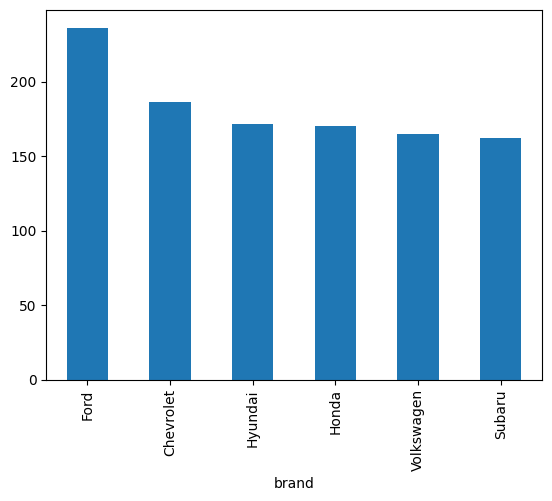

In [477]:
df_marcas_cavalos= df.groupby('brand')['horsepower'].mean().sort_values(ascending=False)
df_marcas_cavalos.plot(kind='bar')

<Axes: xlabel='brand'>

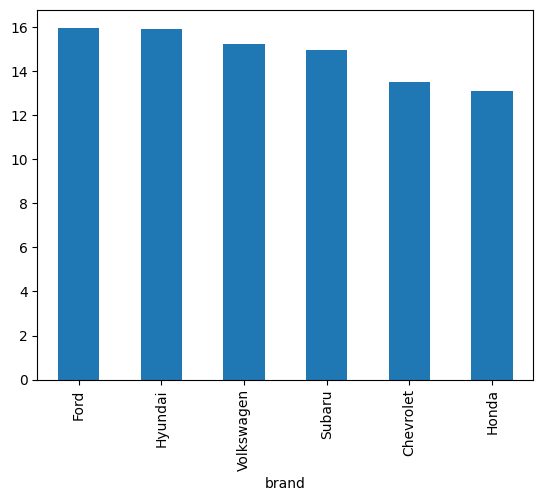

In [478]:
df_marcas_combustivel= df.groupby('brand')['fuel_capacity'].mean().sort_values(ascending=False)
df_marcas_combustivel.plot(kind='bar')

In [479]:
df['year'].unique()

array([2019, 2017, 2014, 2016, 2022, 2015, 2018, 2020])

<Axes: xlabel='brand'>

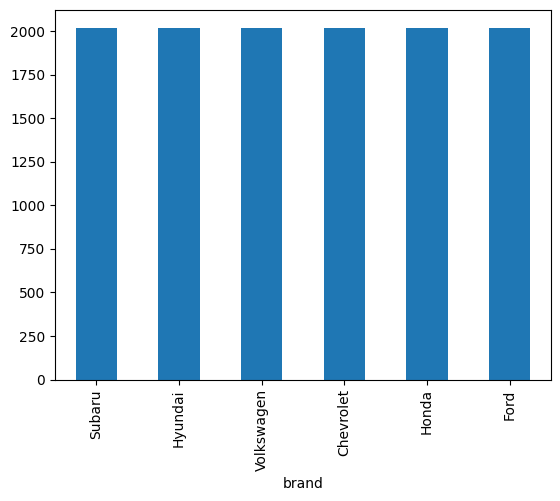

In [480]:
df_marcas_combustivel= df.groupby('brand')['year'].mean().sort_values(ascending=False)
df_marcas_combustivel.plot(kind='bar')

<Axes: xlabel='price', ylabel='miles'>

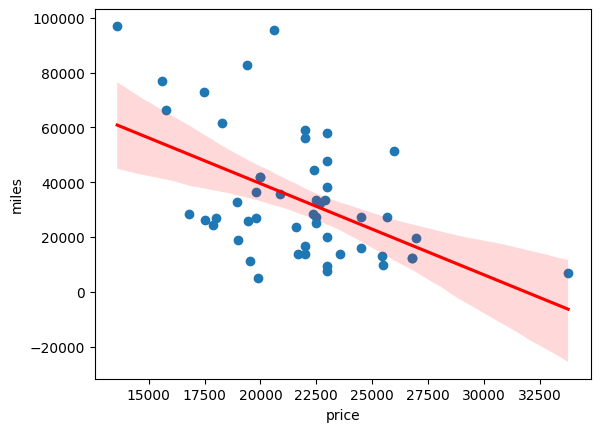

In [481]:
sns.regplot(data=df, x='price', y='miles', scatter_kws={'alpha':1}, line_kws={'color':'red'})

<Axes: xlabel='price', ylabel='horsepower'>

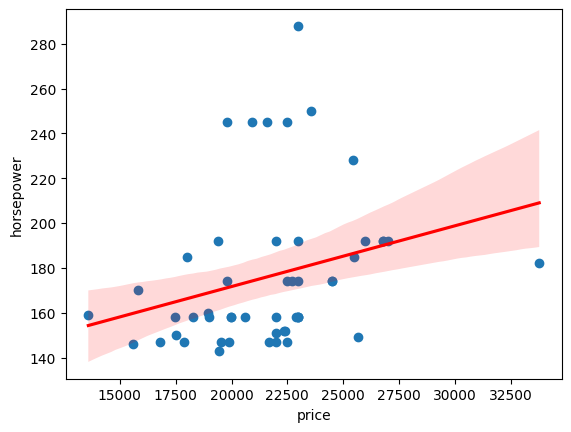

In [482]:
sns.regplot(data=df, x='price', y='horsepower', scatter_kws={'alpha':1}, line_kws={'color':'red'})

<Axes: xlabel='price', ylabel='fuel_capacity'>

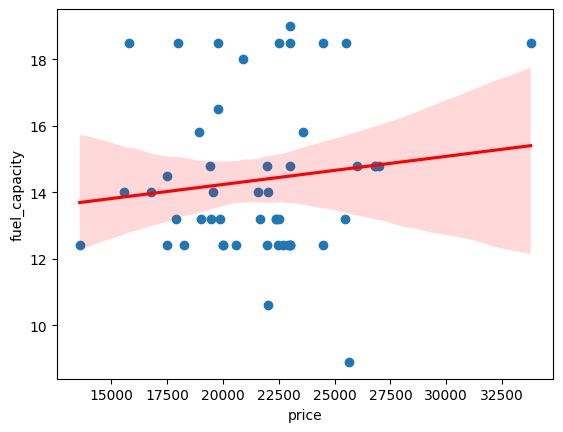

In [483]:
sns.regplot(data=df, x='price', y='fuel_capacity', scatter_kws={'alpha':1}, line_kws={'color':'red'})

<Axes: xlabel='price', ylabel='year'>

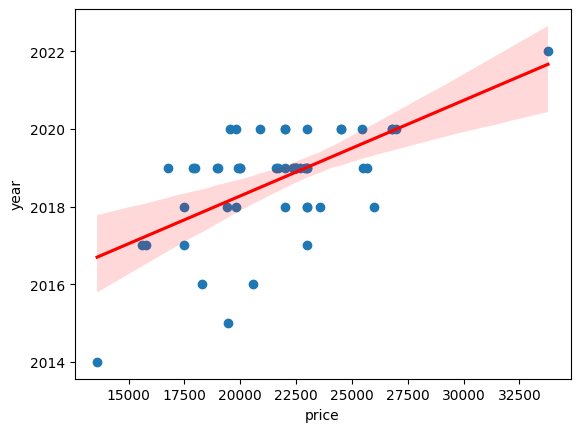

In [484]:
sns.regplot(data=df, x='price', y='year', scatter_kws={'alpha':1}, line_kws={'color':'red'})

<Axes: xlabel='engine_type'>

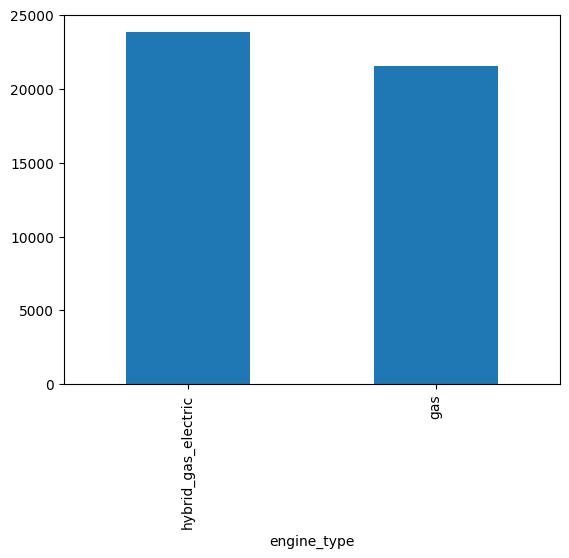

In [485]:
df_motor_medias = df.groupby('engine_type')['price'].mean().sort_values(ascending=False)
df_motor_medias.plot(kind='bar')

<Axes: xlabel='engine_type'>

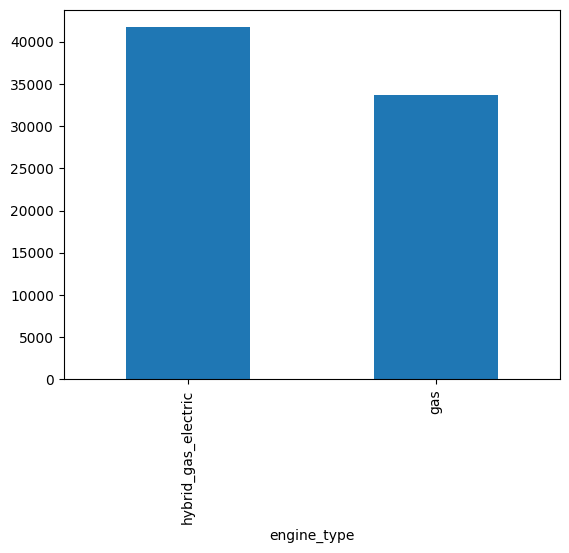

In [486]:
df_motor_milhagem = df.groupby('engine_type')['miles'].mean().sort_values(ascending=False)
df_motor_milhagem.plot(kind='bar')

<Axes: ylabel='price'>

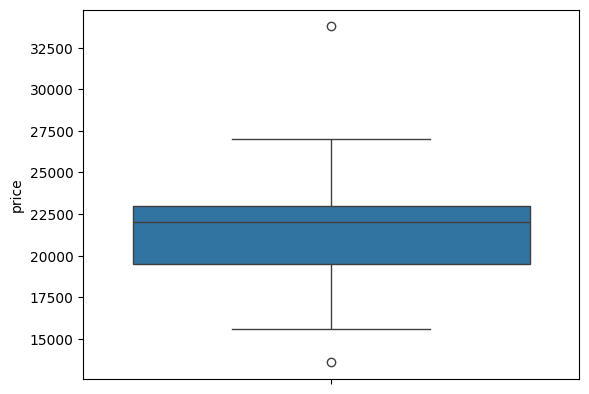

In [487]:
sns.boxplot(data=df, y='price')

In [488]:
maximo = df[df['price'] == df['price'].max()]
minimo = df[df['price'] == df['price'].min()]

In [489]:
df = df[~df.index.isin(maximo.index)]
df = df[~df.index.isin(minimo.index)]

## Passo 3

Com base em suas análises exploratórias, formule hipóteses estatísticas. Valide os testes e explique se as hipóteses foram aceitas.

In [490]:
df['engine_type'].unique()

array(['hybrid_gas_electric', 'gas'], dtype=object)

In [491]:
df['engine_type'].value_counts()

,count
engine_type,
gas,47
hybrid_gas_electric,2


(array([ 2.,  3.,  5.,  8.,  2.,  8., 11.,  3.,  3.,  4.]),
 array([15590. , 16729.8, 17869.6, 19009.4, 20149.2, 21289. , 22428.8,
        23568.6, 24708.4, 25848.2, 26988. ]),
 <BarContainer object of 10 artists>)

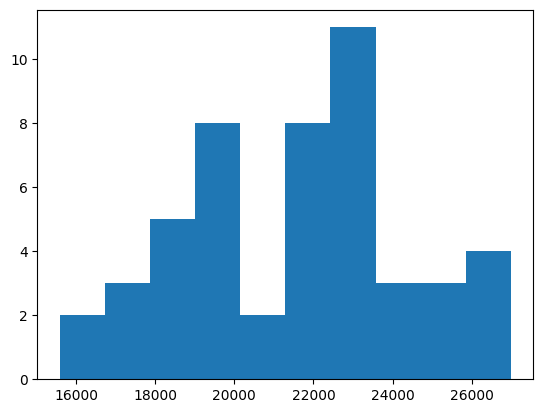

In [492]:
plt.hist(df['price'])

In [493]:
from scipy.stats import shapiro

In [494]:
df_gas = df[df['engine_type'] == 'gas']['price']
df_hibrido = df[df['engine_type'] == 'hybrid_gas_electric']['price']

(array([ 2.,  3.,  5.,  8.,  2.,  7., 11.,  3.,  2.,  4.]),
 array([15590. , 16729.8, 17869.6, 19009.4, 20149.2, 21289. , 22428.8,
        23568.6, 24708.4, 25848.2, 26988. ]),
 <BarContainer object of 10 artists>)

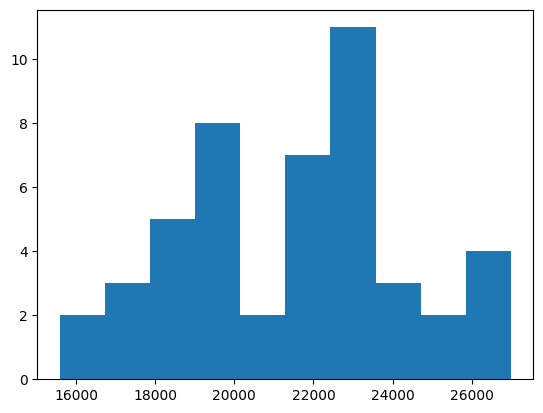

In [495]:
plt.hist(df_gas)

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([21998. , 22363.7, 22729.4, 23095.1, 23460.8, 23826.5, 24192.2,
        24557.9, 24923.6, 25289.3, 25655. ]),
 <BarContainer object of 10 artists>)

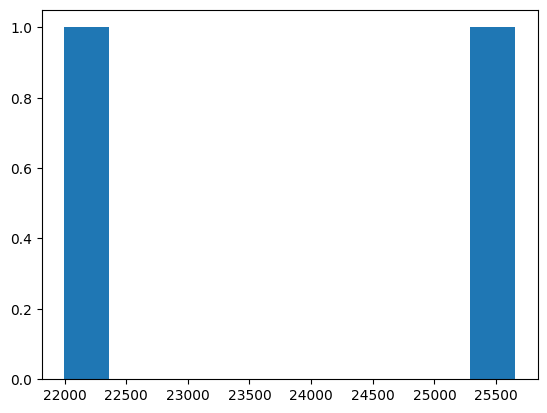

In [496]:
plt.hist(df_hibrido)

In [497]:
stat, p = shapiro(df_gas)

In [498]:
print('Estatística de Teste: {:.4f}, valor p: {}'.format(stat, p))
if p > 0.05:
    print('Não há evidência suficiente para rejeitar a hipótese de normalidade.')
else:
    print('A hipótese de normalidade é rejeitada.')

Estatística de Teste: 0.9741, valor p: 0.37732884403618716
Não há evidência suficiente para rejeitar a hipótese de normalidade.


In [499]:
stat, p = shapiro(df_hibrido)

/tmp/ipython-input-499-1534592725.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = shapiro(df_hibrido)


In [500]:
print('Estatística de Teste: {:.4f}, valor p: {}'.format(stat, p))
if p > 0.05:
    print('Não há evidência suficiente para rejeitar a hipótese de normalidade.')
else:
    print('A hipótese de normalidade é rejeitada.')

Estatística de Teste: nan, valor p: nan
A hipótese de normalidade é rejeitada.


In [501]:
from scipy.stats import mannwhitneyu

In [502]:
stat, p = mannwhitneyu(df_gas.sample(len(df_gas)), df_hibrido.sample(len(df_hibrido)),  alternative='less')

In [503]:
alpha = 0.05
if p < alpha:
    print('Diferença estatisticamente significante')
else:
    print('Não há diferença estatisticamente significante')

Não há diferença estatisticamente significante


## Passo 4

Realize uma análise de correlação entre as variáveis e identifique se o modelo possui variáveis correlacionadas ou não, explicando os motivos e considerações

In [504]:
df.drop(columns = ['id','num_seat','doors'], inplace=True)

<Axes: >

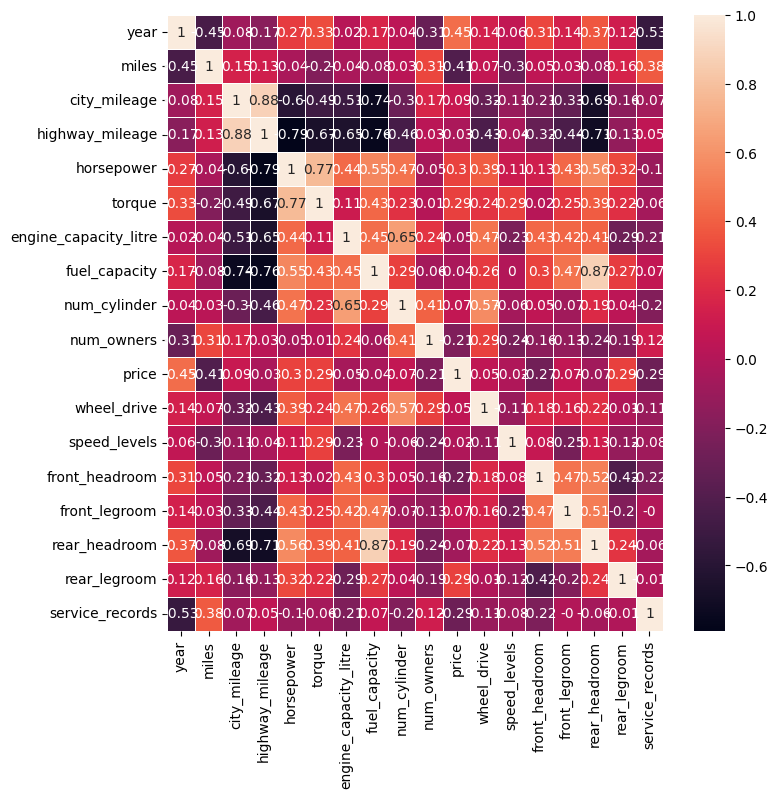

In [505]:
correlation_matrix = df.corr(numeric_only=True).round(2)

fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax)

In [506]:
df_correlacao_preco = df.corr(numeric_only=True)['price'].sort_values(ascending=False)

In [507]:
df_correlacao_preco

,price
price,1.000000
year,0.445001
horsepower,0.304293
torque,0.292206
rear_legroom,0.286407
city_mileage,0.087078
num_cylinder,0.071818
front_legroom,0.069863
wheel_drive,0.046295
speed_levels,-0.020991


<Axes: >

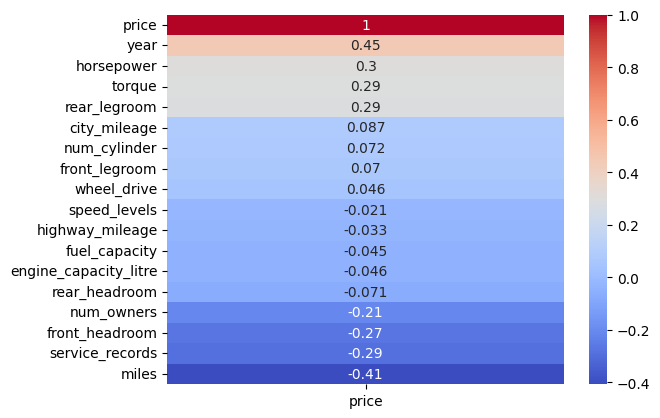

In [508]:
sns.heatmap(df_correlacao_preco.to_frame(), annot=True, cmap='coolwarm')

## Passo 5

Identifique, com base nos dados, um cenário para construção de um modelo de regressão. Aponte qual a variável target configurada para o modelo e quais as variáveis independentes que vão ser utilizadas para prever a sua target dependente.

In [649]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

In [650]:
X = df[['year', 'horsepower', 'torque', 'num_owners', 'miles']].values
y = df['price'].values

In [651]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 101)

In [652]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [653]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [654]:
model_dtr = DecisionTreeRegressor(random_state=7, max_depth=10)
model_dtr.fit(X_train, y_train)
y_pred_model_dtr = model_dtr.predict(X_test)

In [655]:
svr = SVR(kernel='linear')
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

In [656]:
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.053, max_depth=9, subsample = 0.2, random_state=101)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)

## Passo 6

Comprove estatisticamente se o modelo construido possui potencial preditivo utilizando métricas estatísticas

In [657]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [658]:
print("Regressão Linear:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

Regressão Linear:
MAE: 2828.7384938145524
MSE: 11016676.997247208
R²: -0.46113144597042166


In [659]:
print("Decision Tree:")
print("MAE:", mean_absolute_error(y_test, y_pred_model_dtr))
print("MSE:", mean_squared_error(y_test, y_pred_model_dtr))
print("R²:", r2_score(y_test, y_pred_model_dtr))

Decision Tree:
MAE: 1703.1
MSE: 4418294.1
R²: 0.4140058341849632


In [660]:
print("SVR:")
print("MAE:", mean_absolute_error(y_test, y_pred_svr))
print("MSE:", mean_squared_error(y_test, y_pred_svr))
print("R²:", r2_score(y_test, y_pred_svr))

SVR:
MAE: 2729.000208804349
MSE: 10310939.736160979
R²: -0.367530180813624


In [664]:
print("Gradient Boosting:")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("MSE:", mean_squared_error(y_test, y_pred_gb))
print("R²:", r2_score(y_test, y_pred_gb))

Gradient Boosting:
MAE: 1455.5579568811313
MSE: 2931500.77313235
R²: 0.6111978262972972


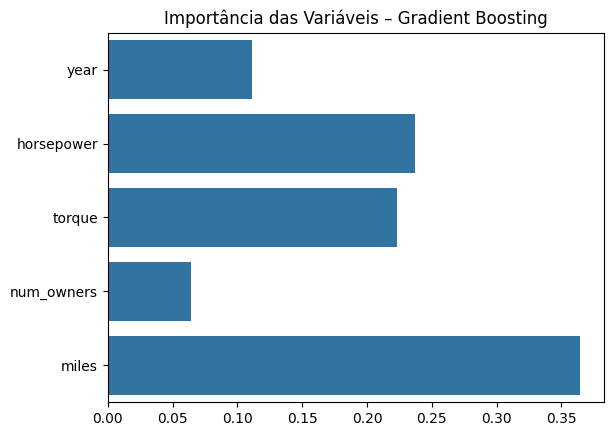

In [665]:
importances = gb.feature_importances_
features = ['year', 'horsepower', 'torque', 'num_owners', 'miles']
sns.barplot(x=importances, y=features)
plt.title('Importância das Variáveis – Gradient Boosting')
plt.show()

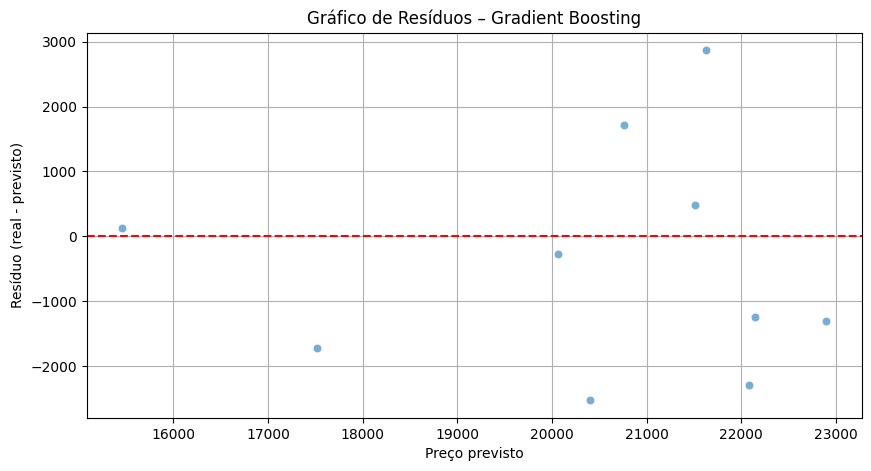

In [666]:
residuals = y_test - y_pred_gb

plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred_gb, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Preço previsto")
plt.ylabel("Resíduo (real - previsto)")
plt.title("Gráfico de Resíduos – Gradient Boosting")
plt.grid(True)
plt.show()